In [1]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

# 数据准备

In [2]:
fread_c("../processed/annotation/RibORF_annot/candidate_ORFs/filtered_v2_20251021/candidateORF.filtered.rmdup.renamed.pep.extended.1.txt/augmented.2.tsv") -> all_orfs

In [3]:
nrow(all_orfs)
table(all_orfs$ORF_type)

[1] 168091


canonical      dORF      iORF noncoding     odORF     ouORF      uORF 
    21861     39593      3589     73667      1059      3387     24935 

In [4]:
all_orfs %>% filter(Geneid=="TYMSOS") %>% print()

                                           ORF_id Isoform_id   Chr Strand
1  PB.20235.1:chr18:-|6|851:102:474|noncoding|ATG PB.20235.1 chr18      -
2 PB.20235.1:chr18:-|38|851:545:656|noncoding|CTG PB.20235.1 chr18      -
   ORF_type Start_codon Is_uniprot Is_canonical ORF_length
1 noncoding         ATG      FALSE        FALSE        123
2 noncoding         CTG      FALSE        FALSE         36
                                                                                                                      ORF_seq
1 MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPGRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS
2                                                                                        MDIGCIRSSYLKKKKKGSNDQNTNKLLTDSVYFFLE
  Isoform_structural_category Isoform_subcategory Geneid Gene_type RPF_reads
1           full-splice_match    alternative_3end TYMSOS    lncRNA       183
2           full-splice_match    alternative_3end TYMSOS    lncRNA   

In [5]:
# 增加frame0的比例
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/peri/psite_frame_stats.v2.tsv") -> orfs_peri
head(orfs_peri,1)
# 增加MS ORF信息
ms_orfs_path <- "/home/user/data3/lit/project/sORFs/02-Mass-spec-20250723/analysis/20251119_new_db_search_res_add_public/results/augment_orf_table/augmented.tsv"
fread_c(ms_orfs_path) -> ms_orfs
ms_orfs %>% filter(!grepl("Cont",ORF_id)) -> ms_orfs
head(ms_orfs,1)
# 增加de novo信息【只对非经典的ORF进行了de novo状态的鉴定】
fread_c("/home/user/data3/lit/project/sORFs/05-denovo-status/analysis/20251029_denovo_check/results/res_filter_paralog_ortholog.txt") -> res_filter_paralog_ortholog
head(res_filter_paralog_ortholog,1)

,ORF_id,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,36,12,0,0,0,0,0,0


,ORF_id,ORF_type,Start_codon,Isoform_id,Chr,Strand,ORF_seq,ORF_length,Geneid,Isoform_structural_category,⋯,N,C,A,Gene_type,Unique_peptide_n,Unique_peptide_n_msfragger_closed,mean_relative_iBAQ,ORF_start,ORF_end,CDS_seq
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,canonical,ATG,PB.10027.4,chr12,-,MATLKEKLIAPVAEEEATVPNNKITVVGVGQVGMACAISILGKSLADELALVDVLEDKLKGEMMDLQHGSLFLQTPKIVADKDYSVTANSKIVVVTAGVRQQEGESRLNLVQRNVNVFKFIIPQIVKYSPDCIIIVVSNPVDILTYVTWKLSGLPKHRVIGSGCNLDSARFRYLMAEKLGIHPSSCHGWILGEHGDSSVAVWSGVNVAGVSLQELNPEMGTDNDSENWKEVHKMVVESAYEVIKLKGYTNWAIGLSVADLIESMLKNLSRIHPVSTMVKGMYGIENEVFLSLPCILNARGLTSVINQKLKDDEVAQLKKSADTLWDIQKDLKDL,334,LDHB,full-splice_match,⋯,0.3698762,0.07221995,0.2210481,protein_coding,52,36,0.001852398,21635541,21654671,ATGGCAACTCTTAAGGAAAAACTCATTGCACCAGTTGCGGAAGAAGAGGCAACAGTTCCAAACAATAAGATCACTGTAGTGGGTGTTGGACAAGTTGGTATGGCGTGTGCTATCAGCATTCTGGGAAAGTCTCTGGCTGATGAACTTGCTCTTGTGGATGTTTTGGAAGATAAGCTTAAAGGAGAAATGATGGATCTGCAGCATGGGAGCTTATTTCTTCAGACACCTAAAATTGTGGCAGATAAAGATTATTCTGTGACCGCCAATTCTAAGATTGTAGTGGTAACTGCAGGAGTCCGTCAGCAAGAAGGGGAGAGTCGGCTCAATCTGGTGCAGAGAAATGTTAATGTCTTCAAATTCATTATTCCTCAGATCGTCAAGTACAGTCCTGATTGCATCATAATTGTGGTTTCCAACCCAGTGGACATTCTTACGTATGTTACCTGGAAACTAAGTGGATTACCCAAACACCGCGTGATTGGAAGTGGATGTAATCTGGATTCTGCTAGATTTCGCTACCTTATGGCTGAAAAACTTGGCATTCATCCCAGCAGCTGCCATGGATGGATTTTGGGGGAACATGGCGACTCAAGTGTGGCTGTGTGGAGTGGTGTGAATGTGGCAGGTGTTTCTCTCCAGGAATTGAATCCAGAAATGGGAACTGACAATGATAGTGAAAATTGGAAGGAAGTGCATAAGATGGTGGTTGAAAGTGCCTATGAAGTCATCAAGCTAAAAGGATATACCAACTGGGCTATTGGATTAAGTGTGGCTGATCTTATTGAATCCATGTTGAAAAATCTATCCAGGATTCATCCCGTGTCAACAATGGTAAAGGGGATGTATGGCATTGAGAATGAAGTCTTCCTGAGCCTTCCATGTATCCTCAATGCCCGGGGATTAACCAGCGTTATCAACCAGAAGCTAAAGGATGATGAGGTTGCTCAGCTCAAGAAAAGTGCAGATACCCTGTGGGACATCCAGAAGGACCTAAAAGACCTG


,orf_id,ev_age,syn_age,denovo,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog,lineage_n,Outgroup Homolog n
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>
1,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,mammal,mammal,1,placentalia,1,1,1,human,8,1


In [6]:
nrow(ms_orfs)

[1] 27613

In [7]:
# MS证据生成逻辑值
ms_orfs$MS_evidence_level_1 <- TRUE
ms_orfs <- mutate(ms_orfs, 
    MS_evidence_level_2 = Run_occurrence > 1,
    MS_evidence_level_3 = Unique_peptide_n > 1
)
merge(all_orfs,orfs_peri,by="ORF_id")  %>% 
merge(ms_orfs[,c("ORF_id","MS_evidence_level_1","MS_evidence_level_2","MS_evidence_level_3")],by="ORF_id",all.x=T)  %>% 
merge(res_filter_paralog_ortholog,by="ORF_id",by.y="orf_id",all.x=T) -> all_orfs_1
colnames(all_orfs_1)

[1] "ORF_id"                      "Isoform_id"                 
 [3] "Chr"                         "Strand"                     
 [5] "ORF_type"                    "Start_codon"                
 [7] "Is_uniprot"                  "Is_canonical"               
 [9] "ORF_length"                  "ORF_seq"                    
[11] "Isoform_structural_category" "Isoform_subcategory"        
[13] "Geneid"                      "Gene_type"                  
[15] "RPF_reads"                   "Psites_number"              
[17] "RPF_RPKM"                    "Psites_RPKM"                
[19] "RPF_codon_coverage"          "Psites_codon_coverage"      
[21] "FL"                          "FL_TPM"                     
[23] "N"                           "C"                          
[25] "A"                           "ORF_start"                  
[27] "ORF_end"                     "CDS_seq"                    
[29] "ORF_id_custom"               "Is_PRICE"                   
[31] "Is_RiboCode"                 "Is_RibORF"                  
[33] "CDS_nt_len"                  "n_codons"                   
[35] "frame0"                      "frame1"                     
[37] "frame2"                      "total_psites"               
[39] "frame0_fraction"             "frame0_codon_covered"       
[41] "MS_evidence_level_1"         "MS_evidence_level_2"        
[43] "MS_evidence_level_3"         "ev_age"                     
[45] "syn_age"                     "denovo"                     
[47] "lineage"                     "loc_times_blat"             
[49] "gene_times_blastn"           "gene_times_blastn_pc"       
[51] "Outgroup Homolog"            "lineage_n"                  
[53] "Outgroup Homolog n"

In [8]:
# Ribo-seq证据生成逻辑值

# 提取Is列（排除Is_canonical）
is_cols <- c("Is_PRICE", "Is_RiboCode", "Is_RibORF")

# 计算每行TRUE的数量
n_tools <- rowSums(all_orfs_1[, is_cols] == "TRUE", na.rm = TRUE)

# 添加新列
all_orfs_1$Is_identified_by_over_1_tools <- n_tools >= 1
all_orfs_1$Is_identified_by_over_2_tools <- n_tools >= 2

all_orfs_1 %>% mutate(Is_Ribo_ORF_custom=frame0_fraction>=0.5 & Psites_codon_coverage>=0.1) -> all_orfs_1

# all_orfs_1 %>% filter(ORF_length<=150) -> all_orfs_2
all_orfs_1 -> all_orfs_2
nrow(all_orfs_2)

[1] 168091

In [9]:
sum(all_orfs_2$Is_PRICE)
sum(all_orfs_2$Is_RiboCode)
sum(all_orfs_2$Is_RibORF)
sum(all_orfs_2$Is_identified_by_over_1_tools)
sum(all_orfs_2$Is_identified_by_over_2_tools)

[1] 3070

[1] 40709

[1] 51401

[1] 54468

[1] 38196

In [10]:
filter(all_orfs_2,Is_Ribo_ORF_custom) -> all_orfs_3
nrow(all_orfs_3)
21861 /22814    
table(all_orfs_3$Is_Ribo_ORF_custom,all_orfs_3$ORF_type)
table(all_orfs_3$Is_identified_by_over_1_tools,all_orfs_3$ORF_type)
table(all_orfs_3$Is_identified_by_over_2_tools,all_orfs_3$ORF_type)

[1] 168091

[1] 0.9582274

      
       canonical  dORF  iORF noncoding odORF ouORF  uORF
  TRUE     21861 39593  3589     73667  1059  3387 24935

       
        canonical  dORF  iORF noncoding odORF ouORF  uORF
  FALSE      1582 36435  3305     53104   877  2077 16243
  TRUE      20279  3158   284     20563   182  1310  8692

       
        canonical  dORF  iORF noncoding odORF ouORF  uORF
  FALSE      3243 38920  3535     59479   984  2732 21002
  TRUE      18618   673    54     14188    75   655  3933

# 统计

In [11]:
get_evidence_table <- function(df){
    library(dplyr)

# 创建统计表格
stats_table <- bind_rows(
    # 第1行：整个数据框，不过滤
    df %>% 
        summarise(
            Condition = "Is_Ribo_ORF_custom",
            Total = n(),
            MS_evidence_level_1 = sum(MS_evidence_level_1, na.rm = TRUE),
            MS_evidence_level_2 = sum(MS_evidence_level_2, na.rm = TRUE),
            MS_evidence_level_3 = sum(MS_evidence_level_3, na.rm = TRUE)
        ),
    # 第2行：过滤 Is_identified_by_over_1_tools == TRUE
    df %>% 
        filter(Is_identified_by_over_1_tools == TRUE) %>%
        summarise(
            Condition = "Is_identified_by_over_1_tools",
            Total = n(),
            MS_evidence_level_1 = sum(MS_evidence_level_1, na.rm = TRUE),
            MS_evidence_level_2 = sum(MS_evidence_level_2, na.rm = TRUE),
            MS_evidence_level_3 = sum(MS_evidence_level_3, na.rm = TRUE)
        ),
    # 第3行：过滤 Is_identified_by_over_2_tools == TRUE
    df %>% 
        filter(Is_identified_by_over_2_tools == TRUE) %>%
        summarise(
            Condition = "Is_identified_by_over_2_tools",
            Total = n(),
            MS_evidence_level_1 = sum(MS_evidence_level_1, na.rm = TRUE),
            MS_evidence_level_2 = sum(MS_evidence_level_2, na.rm = TRUE),
            MS_evidence_level_3 = sum(MS_evidence_level_3, na.rm = TRUE)
        )
)
return(stats_table)
# print(stats_table)
}

In [42]:
get_evidence_table(all_orfs_3) -> df
df
get_evidence_table(all_orfs_3 %>% filter(Is_canonical=="TRUE"))
get_evidence_table(all_orfs_3 %>% filter(Is_canonical=="FALSE"))
get_evidence_table(all_orfs_3 %>% filter(lineage!=""))

Condition,Total,MS_evidence_level_1,MS_evidence_level_2,MS_evidence_level_3
<chr>,<int>,<int>,<int>,<int>
Is_Ribo_ORF_custom,168091,27613,13781,10830
Is_identified_by_over_1_tools,54468,13935,9649,8584
Is_identified_by_over_2_tools,38196,11431,8537,7762


Condition,Total,MS_evidence_level_1,MS_evidence_level_2,MS_evidence_level_3
<chr>,<int>,<int>,<int>,<int>
Is_Ribo_ORF_custom,21861,9932,8129,7579
Is_identified_by_over_1_tools,20279,9279,7647,7132
Is_identified_by_over_2_tools,18618,8543,7110,6641


Condition,Total,MS_evidence_level_1,MS_evidence_level_2,MS_evidence_level_3
<chr>,<int>,<int>,<int>,<int>
Is_Ribo_ORF_custom,146230,17681,5652,3251
Is_identified_by_over_1_tools,34189,4656,2002,1452
Is_identified_by_over_2_tools,19578,2888,1427,1121


Condition,Total,MS_evidence_level_1,MS_evidence_level_2,MS_evidence_level_3
<chr>,<int>,<int>,<int>,<int>
Is_Ribo_ORF_custom,7638,7638,2459,1426
Is_identified_by_over_1_tools,1734,1734,737,530
Is_identified_by_over_2_tools,980,980,492,385


In [13]:
df$Condition <- c("R1: All Ribo-ORFs", "R2: 1+ tools", "R3: 2+ tools")
colnames(df)  <- c("Ribo_level","M0","M1","M2","M3")
df

Ribo_level,M0,M1,M2,M3
<chr>,<int>,<int>,<int>,<int>
R1: All Ribo-ORFs,168091,27613,13781,10830
R2: 1+ tools,54468,13935,9649,8584
R3: 2+ tools,38196,11431,8537,7762


## 热图

In [15]:
# 图片保存地址
output_path <- "../figures/new-MS-res-with-public"
create_path(output_path)


Attaching package: ‘scales’


The following object is masked from ‘package:tidyfst’:

    percent


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


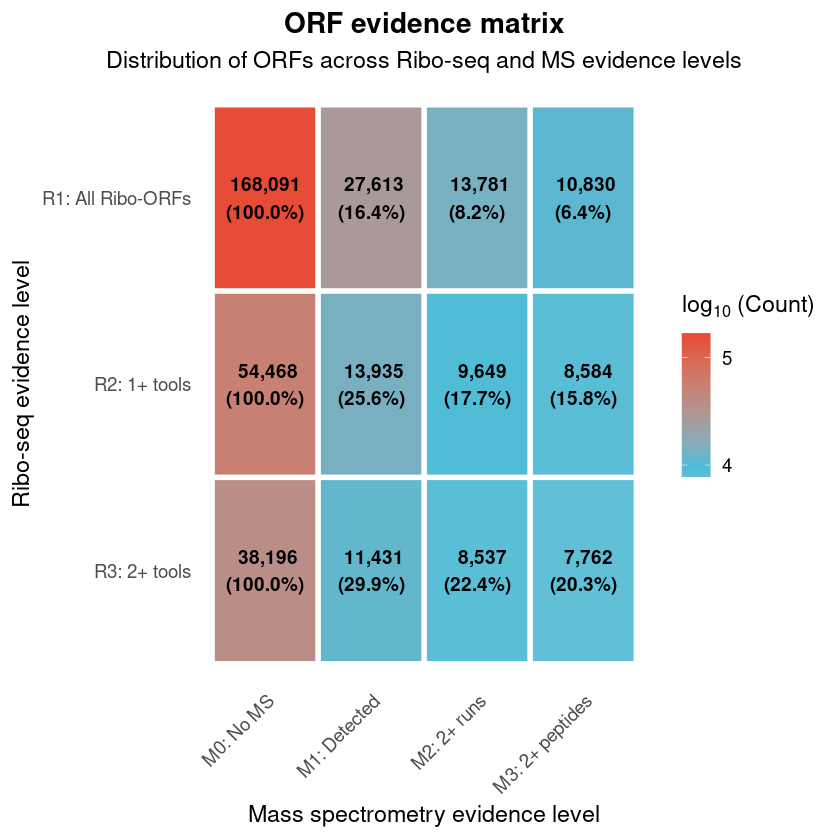

In [16]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 从原始df准备数据（使用你的原始数据）
heatmap_data <- df %>%
    # 选择需要的列
    select(Ribo_level, M0, M1, M2, M3) %>%
    # 转为长格式
    pivot_longer(cols = c(M0, M1, M2, M3), 
                 names_to = "MS_level", 
                 values_to = "count") %>%
    # 设置因子顺序
    mutate(
        Ribo_level = factor(Ribo_level, 
                           levels = c("R3: 2+ tools", "R2: 1+ tools", "R1: All Ribo-ORFs")),
        MS_level = factor(MS_level, levels = c("M0", "M1", "M2", "M3"))
    ) %>%
    # 计算百分比（相对于M0）
    group_by(Ribo_level) %>%
    mutate(
        M0_count = count[MS_level == "M0"],
        percentage = (count / M0_count) * 100
    ) %>%
    ungroup()

# 方案1：使用对数scale（推荐，能更好区分数量差异大的数据）
p1_simple <- ggplot(heatmap_data, aes(x = MS_level, y = Ribo_level, fill = log10(count + 1))) +
    geom_tile(color = "white", size = 1.5) +
    geom_text(aes(label = sprintf("%s\n(%.1f%%)", 
                                  format(count, big.mark = ","), 
                                  percentage)),
              color = "black", size = 4, fontface = "bold") +
    scale_fill_gradient2(
        low = "#E8E8E8",      
        mid = "#4DBBD5",      
        high = "#E64B35",     
        midpoint = 4, 
#         limits = c(2, 5), 
        breaks = c(3, 4, 5),
        labels = c( "3", "4", "5"),
        name = expression(log[10]~"(Count)")
    ) +
    labs(
        x = "Mass spectrometry evidence level",
        y = "Ribo-seq evidence level",
        title = "ORF evidence matrix",
        subtitle = "Distribution of ORFs across Ribo-seq and MS evidence levels"
    ) +
    scale_x_discrete(labels = c("M0: No MS", "M1: Detected", 
                                "M2: 2+ runs", "M3: 2+ peptides")) +
    scale_y_discrete(labels = c("R3: 2+ tools", "R2: 1+ tools", "R1: All Ribo-ORFs")) +
    theme_minimal(base_size = 14) +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid = element_blank(),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.subtitle = element_text(hjust = 0.5)
    )

ggsave(o("orf_evidence_heatmap_log_simple.pdf"), p1_simple, width = 10, height = 6)
print(p1_simple)

# 得到不同的list来进行比较


## 所有小于150aa的de novo基因（共7216个）

In [17]:
all_orfs_3 %>% filter(ORF_length<=150)  %>% filter(lineage!="") %>% filter(Is_Ribo_ORF_custom&MS_evidence_level_1) -> res
table(res$lineage)
nrow(res)
# fwrite_c(res,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/denovo_orfs.lt.150aa.txt")


boreoeutheria    catarrhini      hominoid         human        mammal 
          637          1630          1276           859           253 
  placentalia      primates primatomorpha   simiiformes 
          821           214            47          1479 

[1] 7216

## 随机抽取2500个非经典的蛋白（<=150aa）【虽然整合了public数据，由于是随机抽取，这部分保持不变】

In [18]:
nrow(all_orfs_3)
all_orfs_3 %>% filter(MS_evidence_level_1&Is_Ribo_ORF_custom) %>% filter(Is_canonical=="FALSE") -> non_cano_orfs
nrow(non_cano_orfs)
# set.seed(123)  # 设置随机种子以保证结果可重复
# non_cano_orfs.sample.2.5k <- non_cano_orfs %>% filter(ORF_length<=150) %>% 
#     sample_n(2500)
# nrow(non_cano_orfs.sample.2.5k)
# fwrite_c(non_cano_orfs.sample.2.5k,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/non_cano_orfs.sample.2.5k.lt.150aa.txt")

[1] 168091

[1] 17681

## 随机抽取2500个非经典的ORF【虽然整合了public数据，由于是随机抽取，这部分保持不变】

In [19]:
nrow(all_orfs_3)
all_orfs_3 %>% filter(is.na(MS_evidence_level_1) & Is_Ribo_ORF_custom) %>% filter(Is_canonical=="FALSE") -> r1_m_minus_non_cano_orfs
nrow(r1_m_minus_non_cano_orfs)
# set.seed(123)  # 设置随机种子以保证结果可重复
# r1_m_minus_non_cano_orfs.sample.2.5k <- r1_m_minus_non_cano_orfs %>% filter(ORF_length<=150) %>% 
#     sample_n(2500)
# nrow(r1_m_minus_non_cano_orfs.sample.2.5k)
# fwrite_c(r1_m_minus_non_cano_orfs.sample.2.5k,"/home/user/data3/lit/project/sORFs/10-feature-egi/processed/seve_list_compare/r1_m_minus_non_cano_orfs.sample.2.5k.lt.150aa.txt")

[1] 168091

[1] 128549

# 查看和ZNF271P基因的重叠

In [20]:
all_orfs_3 %>% filter(Geneid=="ZNF271P") %>% filter(Is_identified_by_over_2_tools) %>% print()

                                               ORF_id   Isoform_id   Chr Strand
1  PB.20625.144:chr18:+|25|2434:449:764|noncoding|ATG PB.20625.144 chr18      +
2   PB.20625.144:chr18:+|4|2434:125:233|noncoding|ATG PB.20625.144 chr18      +
3 PB.20625.144:chr18:+|50|2434:949:2221|noncoding|ATG PB.20625.144 chr18      +
4   PB.20625.145:chr18:+|8|2055:164:218|noncoding|ATG PB.20625.145 chr18      +
   ORF_type Start_codon Is_uniprot Is_canonical ORF_length
1 noncoding         ATG      FALSE        FALSE        104
2 noncoding         ATG      FALSE        FALSE         35
3 noncoding         ATG      FALSE        FALSE        423
4 noncoding         ATG      FALSE        FALSE         17
                                                                                                                                                                                                                                                                                                                 

# 查看和de novo基因的重叠

In [21]:
 fread("/home/user/data3/lit/project/sORFs/02-Mass-spec-20250723/analysis/20251028_new_db_search_res/MS_res_from_Galaxy/denovo_37.tsv") -> denovo_37
head(denovo_37)
gsub(pattern = "\\*",replacement = "",denovo_37$Coding.Sequence) -> denovo_37$Coding.Sequence.remove.stop

Gene.ID,Gene.Name,Transcript.ID,Protein.Age,Chromosome,Strand,Number.of.Exons,CDS.Start.Coords,CDS.End.Coords,Protein.Length,Coding.Sequence
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
ENSG00000100433,KCNK10,ENST00000340700,human,14,-,7,88181857,88182306,149,MFRFHTKKEHTSTIFSGGCLLLHWQAGTEFFLHDKSGGLLVREPMGIFSWKEYSSIPSPNPTVIFITLGQGCIECVCVCVCVCVCVCVCVRVGVVLGHLWPVTKVTRTICVPAVIACDCGCISSLPRSLVTLSAHQGRELSTDTCQGPL*
ENSG00000120742,SERP1,ENST00000490945,hominoid,3,-,2,"150567021,150602944","150567106,150603082",74,MYEADVSSASSFAIYPFTCLRLGNTYFIVLIQVLADGREETPDPQNEINGFSKAAHQTVKVVIPLHLTCSQRGE*
ENSG00000145063,ENSG00000145063,ENST00000544306,human,2,-,5,"11105618,11120763,11124583,11128721","11105662,11120962,11124785,11128797",174,MGLLSQRKWTLSGSQQTGCVALTVPSFPWVASRMHYGRKQVSWIIFLKIGAGCQVHVGHDCSTLRRQQGAPWSFASSFRPAASPLAPPSPGVSGLFPPHERWSGGSQTRCGKCVKMQILGSTLKLFRHPPSQVTRLWGRHHLKTPAPFLQSPGIQLNPGKVPASLLRLATWKPL*
ENSG00000167645,YIF1B,ENST00000339413,human,19,-,8,38304451,38304879,142,MLSCCLEPAAWDCGAEGRDGREEMVLGWKRDRGTTPRTLPASPSAGTPLWGAGHVLGDAGESPLPSHPCPNRWSCCWSRKSCGVLAGWRCGSEAAPLTQPPEVGGLRQDPGVRGNPSLPAPPQPVMRRLTFGPGPAPASDRP*
ENSG00000172927,MYEOV,ENST00000308946,human,11,+,3,"69295355,69295592","69295495,69296392",313,MALRICVTYTPALPIGLCTRCCLCLEQSPSWCHCLRGVSFLTFHLHQSVPLGDRDSLLMFTRQAGHFVEGSKAGRSRGRLCLSQALRVAVRGAFVSLWFAAGAGDRERNKGDKGAQTGAGLSQEAEDVDVSRARRVTDAPQGTLCGTGNRNSGSQSARVVGVAHLGEAFRVGVEQAISSCPEEVHGRHGLSMEIMWARMDVALRSPGRGLLAGAGALCMTLAESSCPDYERGRRACLTLHRHPTPHCSTWGLPLRVAGSWLTVVTVEALGGWRMGVRRTGQVGPTMHPPPVSGASPLLLHHLLLLLLIIILTC*
ENSG00000176912,TYMSOS,ENST00000323813,human,18,-,2,657876,658247,123,MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPRRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS*


In [22]:
 merge(all_orfs_3, denovo_37, 
                by.x = c("Geneid", "ORF_length"), 
                by.y = c("Gene.Name", "Protein.Length")) -> all_orfs_denovo_overlap
all_orfs_denovo_overlap

Geneid,ORF_length,ORF_id,Isoform_id,Chr,Strand.x,ORF_type,Start_codon,Is_uniprot,Is_canonical,⋯,Gene.ID,Transcript.ID,Protein.Age,Chromosome,Strand.y,Number.of.Exons,CDS.Start.Coords,CDS.End.Coords,Coding.Sequence,Coding.Sequence.remove.stop
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
EIF3J-DT,86,PB.15800.19:chr15:-|17|1231:241:502|noncoding|ATG,PB.15800.19,chr15,-,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000179523,ENST00000313807,hominoid,15,-,2,44536401,44536661,MAACGYPRRAQKRALRPRPPVGSVAGLPGPQRESSRARWRGPLWNPAIPGRRCRSGWGEPRSWHVCLELVTKESKRALVFEAFPFL*,MAACGYPRRAQKRALRPRPPVGSVAGLPGPQRESSRARWRGPLWNPAIPGRRCRSGWGEPRSWHVCLELVTKESKRALVFEAFPFL
ENSG00000279491,164,PB.7796.1:chr11:+|23|1105:331:826|noncoding|ATG,PB.7796.1,chr11,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000279491,ENST00000623785,human,11,+,1,61968104,61968598,MIGKVEGGDAVLRWSSAFSLPQSPGRSAMEKWGARRVSGPPLPFRLLRPRLPLAESKYGSVCGFCNKGWAGRVSLGMGTASPGSRGGEPPGPPRESLVSLRTQGTHLGLERRNDVDLKAKPMLRTFQNGLLSAPLTGASGFGGPVGQPWGVIGEKLTGLMAGDR*,MIGKVEGGDAVLRWSSAFSLPQSPGRSAMEKWGARRVSGPPLPFRLLRPRLPLAESKYGSVCGFCNKGWAGRVSLGMGTASPGSRGGEPPGPPRESLVSLRTQGTHLGLERRNDVDLKAKPMLRTFQNGLLSAPLTGASGFGGPVGQPWGVIGEKLTGLMAGDR
EXOC3-AS1,119,PB.36844.2:chr5:-|18|1601:309:669|noncoding|ATG,PB.36844.2,chr5,-,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000221990,ENST00000623673,hominoid,5,-,1,442463,442822,MPAVFMLASSSALQCGRGVPRFPRTEVGAGHSVNEETKAEKVGNQTSVIPATSRQAALGTSWTQRRTQPLQERSHWHPRGNNASGMGGHRMFPGPLRGPAAQVLENECGSLGRAAEGRS*,MPAVFMLASSSALQCGRGVPRFPRTEVGAGHSVNEETKAEKVGNQTSVIPATSRQAALGTSWTQRRTQPLQERSHWHPRGNNASGMGGHRMFPGPLRGPAAQVLENECGSLGRAAEGRS
LINC00632,103,PB.55519.8:chrX:+|4|1389:39:351|noncoding|ATG,PB.55519.8,chrX,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000203930,ENST00000649335,human,X,+,5,"140709797,140711621,140713517","140709805,140711656,140713783",MPLEKFVDMEFLDQMILRGTCLEADLCPQYTNSPFNAHTDQITQTHLPPQHLDSSHSTHTCLPVHRHIQRHTDKHHSKKMFPRTHGHPNPRIIRLSQRHVCTA*,MPLEKFVDMEFLDQMILRGTCLEADLCPQYTNSPFNAHTDQITQTHLPPQHLDSSHSTHTCLPVHRHIQRHTDKHHSKKMFPRTHGHPNPRIIRLSQRHVCTA
LINC02397,55,PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG,PB.11229.2,chr12,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000205056,ENST00000504409,hominoid,12,+,2,92482046,92482213,MERRKSFALDQITALEGKRLQSHSFLRSAMGWDDTHLKKKKKEVTSLASLAKDMN*,MERRKSFALDQITALEGKRLQSHSFLRSAMGWDDTHLKKKKKEVTSLASLAKDMN
MOCS2-DT,85,PB.37504.2:chr5:+|5|3143:66:324|noncoding|ATG,PB.37504.2,chr5,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000247796,ENST00000502171,human,5,+,3,"53109930,53112240","53110148,53112278",MGRGGERKQSVWKWRNGLPCMSFSPGGRSWCRRADARLLDTCRLRYGGLANNLAGVFRLFHWLTFRLLTLLPTIEKRRDSMRLEM*,MGRGGERKQSVWKWRNGLPCMSFSPGGRSWCRRADARLLDTCRLRYGGLANNLAGVFRLFHWLTFRLLTLLPTIEKRRDSMRLEM
ODC1-DT,106,PB.22935.1:chr2:+|11|2526:140:461|noncoding|ATG,PB.22935.1,chr2,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000257135,ENST00000547349,hominoid,2,+,4,10448805,10449125,MCWPRGPRRADSGPCCRPFLRCKGPGSDPGAALLPPAREQRRGREGASRGSPARCGQGWQPPPRPRAGSLVFVTSRYPVTRWVLACGGSFPCEARDSARSVRGPGS*,MCWPRGPRRADSGPCCRPFLRCKGPGSDPGAALLPPAREQRRGREGASRGSPARCGQGWQPPPRPRAGSLVFVTSRYPVTRWVLACGGSFPCEARDSARSVRGPGS
PAX8-AS1,109,PB.24776.2:chr2:+|2|2222:26:356|noncoding|ATG,PB.24776.2,chr2,+,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000189223,ENST00000422956,human,2,+,5,"113235561,113255390,113259264","113235570,113255549,113259423",MAKDTYTHRNELFKEDGPDSTVQKKKRFALLLKESGYECRGLPVGSHIRSSTSTLNASDASPSVNVALGMANPHPALWPSEAQGEKPPRSNLPEPSPSSHRPPQPLSSL*,MAKDTYTHRNELFKEDGPDSTVQKKKRFALLLKESGYECRGLPVGSHIRSSTSTLNASDASPSVNVALGMANPHPALWPSEAQGEKPPRSNLPEPSPSSHRPPQPLSSL
SMIM45,107,PB.29518.5:chr22:+|14|886:162:486|canonical|ATG,PB.29518.5,chr22,+,canonical,ATG,FALSE,TRUE,⋯,ENSG00000205704,ENST00000381348,hominoid,22,+,2,41958217,41958540,MSMAACPEAPEPSFLREVPSSPASTQWHRPCNFRQVEANPRKEPKNLVWRDVSLGQTSRTPRGSGLELVRVCGGGMQRDKTVVEERVGEERERERERVWGERASMGR*,MSMAACPEAPEPSFLREVPSSPASTQWHRPCNFRQVEANPRKEPKNLVWRDVSLGQTSRTPRGSGLELVRVCGGGMQRDKTVVEERVGEERERERERVWGERASMGR


In [23]:
print(all_orfs_denovo_overlap)

            Geneid ORF_length                                            ORF_id
1         EIF3J-DT         86 PB.15800.19:chr15:-|17|1231:241:502|noncoding|ATG
2  ENSG00000279491        164   PB.7796.1:chr11:+|23|1105:331:826|noncoding|ATG
3        EXOC3-AS1        119   PB.36844.2:chr5:-|18|1601:309:669|noncoding|ATG
4        LINC00632        103     PB.55519.8:chrX:+|4|1389:39:351|noncoding|ATG
5        LINC02397         55  PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG
6         MOCS2-DT         85     PB.37504.2:chr5:+|5|3143:66:324|noncoding|ATG
7          ODC1-DT        106   PB.22935.1:chr2:+|11|2526:140:461|noncoding|ATG
8         PAX8-AS1        109     PB.24776.2:chr2:+|2|2222:26:356|noncoding|ATG
9           SMIM45        107   PB.29518.5:chr22:+|14|886:162:486|canonical|ATG
10          TYMSOS        123    PB.20235.1:chr18:-|6|851:102:474|noncoding|ATG
11         UBR5-DT         35   PB.48289.6:chr8:+|18|1835:315:423|noncoding|ATG
    Isoform_id   Chr Strand.x  ORF_type 

In [24]:
get_evidence_table(all_orfs_denovo_overlap)

Condition,Total,MS_evidence_level_1,MS_evidence_level_2,MS_evidence_level_3
<chr>,<int>,<int>,<int>,<int>
Is_Ribo_ORF_custom,11,4,4,4
Is_identified_by_over_1_tools,8,1,1,1
Is_identified_by_over_2_tools,7,0,0,0


In [25]:
all_orfs_denovo_overlap$Geneid
all_orfs_denovo_overlap %>% filter(Is_identified_by_over_1_tools&MS_evidence_level_3)

[1] "EIF3J-DT"        "ENSG00000279491" "EXOC3-AS1"       "LINC00632"      
 [5] "LINC02397"       "MOCS2-DT"        "ODC1-DT"         "PAX8-AS1"       
 [9] "SMIM45"          "TYMSOS"          "UBR5-DT"

Geneid,ORF_length,ORF_id,Isoform_id,Chr,Strand.x,ORF_type,Start_codon,Is_uniprot,Is_canonical,⋯,Gene.ID,Transcript.ID,Protein.Age,Chromosome,Strand.y,Number.of.Exons,CDS.Start.Coords,CDS.End.Coords,Coding.Sequence,Coding.Sequence.remove.stop
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
TYMSOS,123,PB.20235.1:chr18:-|6|851:102:474|noncoding|ATG,PB.20235.1,chr18,-,noncoding,ATG,FALSE,FALSE,⋯,ENSG00000176912,ENST00000323813,human,18,-,2,657876,658247,MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPRRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS*,MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPRRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS


In [26]:
fread_c("/home/user/data3/lit/project/sORFs/05-denovo-status/analysis/20251029_denovo_check/results/all_sep_m_evo_add_homolog.txt") -> all_sep_m_evo_add_homolog
head(all_sep_m_evo_add_homolog,1)

,orf_id,ev_age,syn_age,denovo,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>
1,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,placentalia,mammal,1,placentalia,1,2,2,human


In [27]:
# 因为我们只把ribo+ms+的拿去做de novo起源鉴定了
merge(all_orfs_denovo_overlap,all_sep_m_evo_add_homolog,by.x="ORF_id",by.y="orf_id")

ORF_id,Geneid,ORF_length,Isoform_id,Chr,Strand.x,ORF_type,Start_codon,Is_uniprot,Is_canonical,⋯,Coding.Sequence,Coding.Sequence.remove.stop,ev_age.y,syn_age.y,denovo.y,lineage.y,loc_times_blat.y,gene_times_blastn.y,gene_times_blastn_pc.y,Outgroup Homolog.y
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>
PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG,LINC02397,55,PB.11229.2,chr12,+,noncoding,ATG,FALSE,FALSE,⋯,MERRKSFALDQITALEGKRLQSHSFLRSAMGWDDTHLKKKKKEVTSLASLAKDMN*,MERRKSFALDQITALEGKRLQSHSFLRSAMGWDDTHLKKKKKEVTSLASLAKDMN,hominoid,placentalia,1,hominoid,1,2,0,human
PB.20235.1:chr18:-|6|851:102:474|noncoding|ATG,TYMSOS,123,PB.20235.1,chr18,-,noncoding,ATG,FALSE,FALSE,⋯,MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPRRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS*,MTPASGATASLGRLRARPRSRWDAAYLPAVAAVCVARASHVPNGTLRFGVCKARRTMRPLPRRIEVRTKRGPQRPAAPERSPQPRLPPSRHPSRRGPRRHLSGCSAPACRIPTGCRCPCGRPS,hominoid,placentalia,1,human,1,1,0,human
PB.36844.2:chr5:-|18|1601:309:669|noncoding|ATG,EXOC3-AS1,119,PB.36844.2,chr5,-,noncoding,ATG,FALSE,FALSE,⋯,MPAVFMLASSSALQCGRGVPRFPRTEVGAGHSVNEETKAEKVGNQTSVIPATSRQAALGTSWTQRRTQPLQERSHWHPRGNNASGMGGHRMFPGPLRGPAAQVLENECGSLGRAAEGRS*,MPAVFMLASSSALQCGRGVPRFPRTEVGAGHSVNEETKAEKVGNQTSVIPATSRQAALGTSWTQRRTQPLQERSHWHPRGNNASGMGGHRMFPGPLRGPAAQVLENECGSLGRAAEGRS,catarrhini,boreoeutheria,1,hominoid,1,1,0,human
PB.7796.1:chr11:+|23|1105:331:826|noncoding|ATG,ENSG00000279491,164,PB.7796.1,chr11,+,noncoding,ATG,FALSE,FALSE,⋯,MIGKVEGGDAVLRWSSAFSLPQSPGRSAMEKWGARRVSGPPLPFRLLRPRLPLAESKYGSVCGFCNKGWAGRVSLGMGTASPGSRGGEPPGPPRESLVSLRTQGTHLGLERRNDVDLKAKPMLRTFQNGLLSAPLTGASGFGGPVGQPWGVIGEKLTGLMAGDR*,MIGKVEGGDAVLRWSSAFSLPQSPGRSAMEKWGARRVSGPPLPFRLLRPRLPLAESKYGSVCGFCNKGWAGRVSLGMGTASPGSRGGEPPGPPRESLVSLRTQGTHLGLERRNDVDLKAKPMLRTFQNGLLSAPLTGASGFGGPVGQPWGVIGEKLTGLMAGDR,human,placentalia,1,human,1,1,0,human


# 得到de novo的人或者人科特异的基因【这一部分不更改】

In [28]:
# nrow(all_orfs_3)
# all_orfs_3 %>% filter(lineage=="human"|lineage=="hominoid") -> denovo_list
# nrow(denovo_list)

In [29]:
# denovo_list %>% fwrite_c(path = "/home/user/data3/lit/project/sORFs/11-denovo-list/processed/denovo_list.txt")
# denovo_list  %>% filter(Gene_type=="lncRNA") %>% .$Geneid -> lncRNA_geneid

In [30]:
# length(lncRNA_geneid)
# sum(grepl("-",lncRNA_geneid))
# lncRNA_geneid[grepl("-",lncRNA_geneid)] 
# 161/366

In [31]:
# nrow(denovo_list)
# length(unique(denovo_list$Isoform_id))
# length(unique(denovo_list$Geneid))

# 得到非经典的所有ORFs

In [32]:
all_orfs_3 %>% filter(MS_evidence_level_1&Is_Ribo_ORF_custom) %>% filter(Is_canonical=="FALSE") -> non_cano_orfs
nrow(non_cano_orfs)
# non_cano_orfs %>% fwrite_c(path = "/home/user/data3/lit/project/sORFs/11-denovo-list/processed/non_cano_orfs_r1m1.txt")

[1] 17681

# 可视化Ribo-seq的结果

In [44]:
cols <- c("ORF_id","ORF_length","Start_codon","ORF_type","Is_PRICE","Is_RiboCode","Is_RibORF","Is_Ribo_ORF_custom","MS_evidence_level_1")
head(all_orfs_3)
colnames(all_orfs_3)
all_orfs_3[,cols] %>% head()
all_orfs_3[,cols] -> df

,ORF_id,Isoform_id,Chr,Strand,ORF_type,Start_codon,Is_uniprot,Is_canonical,ORF_length,ORF_seq,⋯,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog,lineage_n,Outgroup Homolog n,Is_identified_by_over_1_tools,Is_identified_by_over_2_tools,Is_Ribo_ORF_custom
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,⋯,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<lgl>,<lgl>,<lgl>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,PB.100.1,chr1,-,noncoding,ATG,FALSE,FALSE,116,MPSHIRKSQARRGRRRRGLPGVSNCGTGGSPWEVVLAPRRGEWSGVRTASQAQVVSLPWMPVGVGTAEPRTLPGDHSQATFPTLPSCSRRQRRPGRSAHRLLVSAALRSGSSALPF,⋯,NA,NA,NA,NA,NA,NA,NA,TRUE,TRUE,TRUE
2,PB.100.1:chr1:-|30|2138:406:496|noncoding|GTG,PB.100.1,chr1,-,noncoding,GTG,FALSE,FALSE,29,MTASGAPAPRHFIDSAVTFLSNSRSGLDV,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,TRUE
3,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,PB.100.1,chr1,-,noncoding,ATG,FALSE,FALSE,60,MSKAPWAAGLWMRRRKPHPLHHPLTRKDTDSFGEGCPVSAGALGRWPWDTVPVPVCVHHV,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,TRUE
4,PB.1000.1:chr1:+|121|1855:1798:1843|dORF|TTG,PB.1000.1,chr1,+,dORF,TTG,FALSE,FALSE,14,MSDVCASFQVLLFK,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,TRUE
5,PB.1000.1:chr1:+|2|1855:92:134|ouORF|TTG,PB.1000.1,chr1,+,ouORF,TTG,FALSE,FALSE,13,MGPHGGDRGVPDA,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,TRUE
6,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,PB.1000.1,chr1,+,iORF,CTG,FALSE,FALSE,21,MAVGGAGDVDQSLQQPHQQSI,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,TRUE


[1] "ORF_id"                        "Isoform_id"                   
 [3] "Chr"                           "Strand"                       
 [5] "ORF_type"                      "Start_codon"                  
 [7] "Is_uniprot"                    "Is_canonical"                 
 [9] "ORF_length"                    "ORF_seq"                      
[11] "Isoform_structural_category"   "Isoform_subcategory"          
[13] "Geneid"                        "Gene_type"                    
[15] "RPF_reads"                     "Psites_number"                
[17] "RPF_RPKM"                      "Psites_RPKM"                  
[19] "RPF_codon_coverage"            "Psites_codon_coverage"        
[21] "FL"                            "FL_TPM"                       
[23] "N"                             "C"                            
[25] "A"                             "ORF_start"                    
[27] "ORF_end"                       "CDS_seq"                      
[29] "ORF_id_custom"                 "Is_PRICE"                     
[31] "Is_RiboCode"                   "Is_RibORF"                    
[33] "CDS_nt_len"                    "n_codons"                     
[35] "frame0"                        "frame1"                       
[37] "frame2"                        "total_psites"                 
[39] "frame0_fraction"               "frame0_codon_covered"         
[41] "MS_evidence_level_1"           "MS_evidence_level_2"          
[43] "MS_evidence_level_3"           "ev_age"                       
[45] "syn_age"                       "denovo"                       
[47] "lineage"                       "loc_times_blat"               
[49] "gene_times_blastn"             "gene_times_blastn_pc"         
[51] "Outgroup Homolog"              "lineage_n"                    
[53] "Outgroup Homolog n"            "Is_identified_by_over_1_tools"
[55] "Is_identified_by_over_2_tools" "Is_Ribo_ORF_custom"

,ORF_id,ORF_length,Start_codon,ORF_type,Is_PRICE,Is_RiboCode,Is_RibORF,Is_Ribo_ORF_custom,MS_evidence_level_1
,<chr>,<int>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,FALSE,TRUE,TRUE,TRUE,TRUE
2,PB.100.1:chr1:-|30|2138:406:496|noncoding|GTG,29,GTG,noncoding,FALSE,FALSE,FALSE,TRUE,NA
3,PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,60,ATG,noncoding,FALSE,FALSE,FALSE,TRUE,TRUE
4,PB.1000.1:chr1:+|121|1855:1798:1843|dORF|TTG,14,TTG,dORF,FALSE,FALSE,FALSE,TRUE,NA
5,PB.1000.1:chr1:+|2|1855:92:134|ouORF|TTG,13,TTG,ouORF,FALSE,FALSE,FALSE,TRUE,NA
6,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,21,CTG,iORF,FALSE,FALSE,FALSE,TRUE,TRUE


## 作图

png 
  2

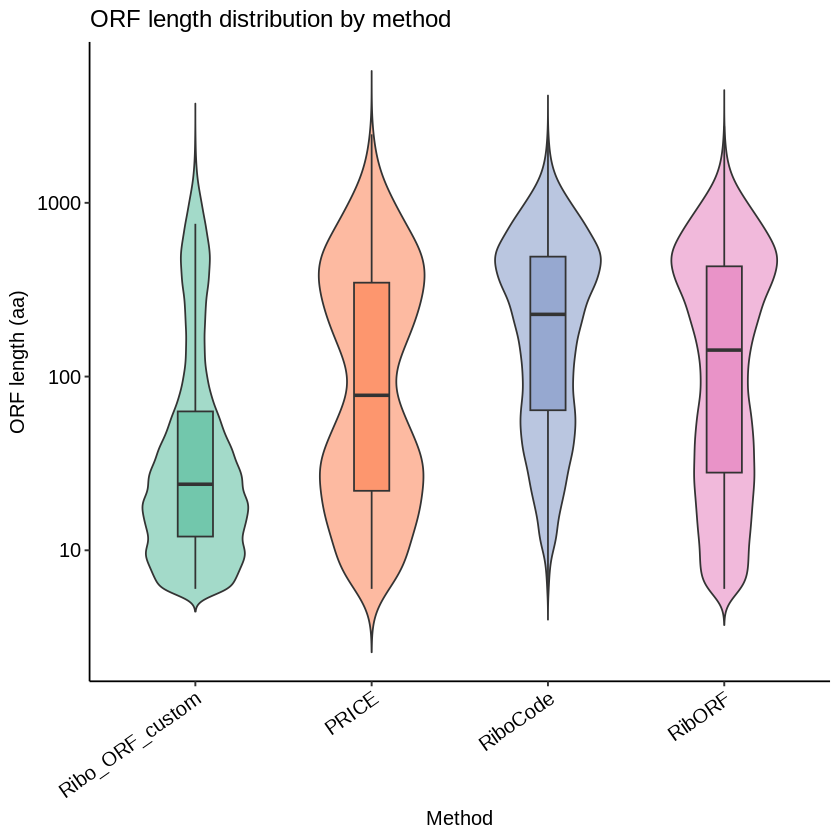

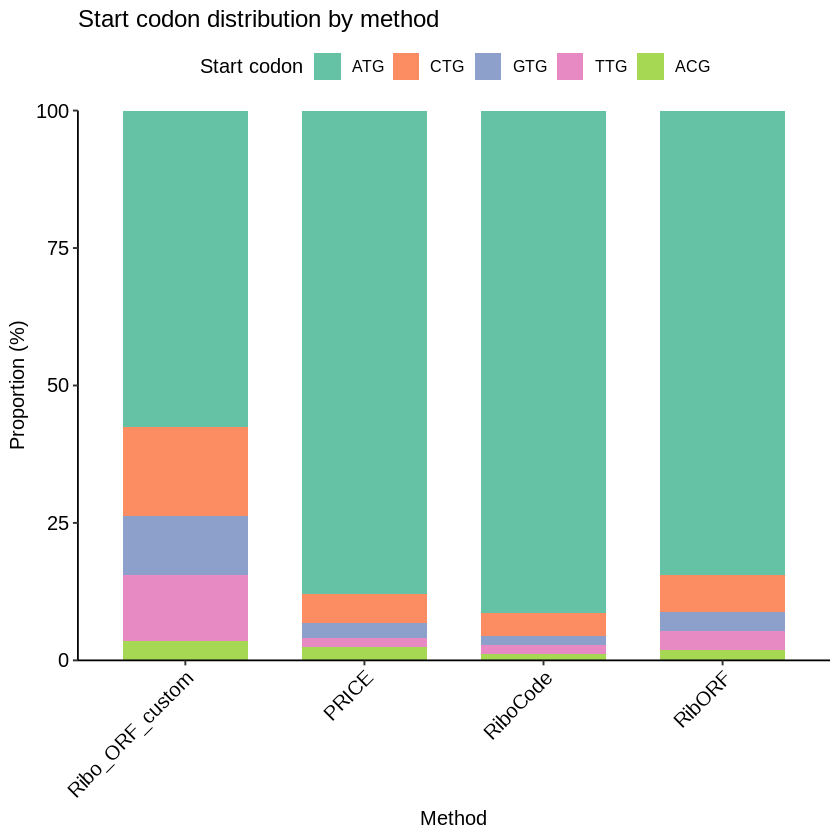

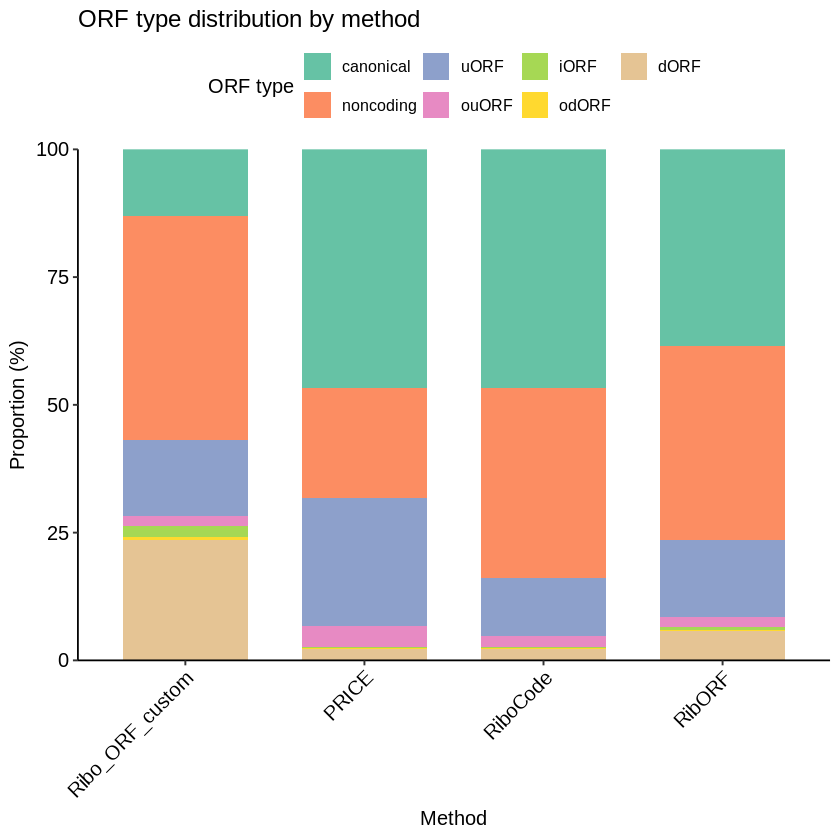

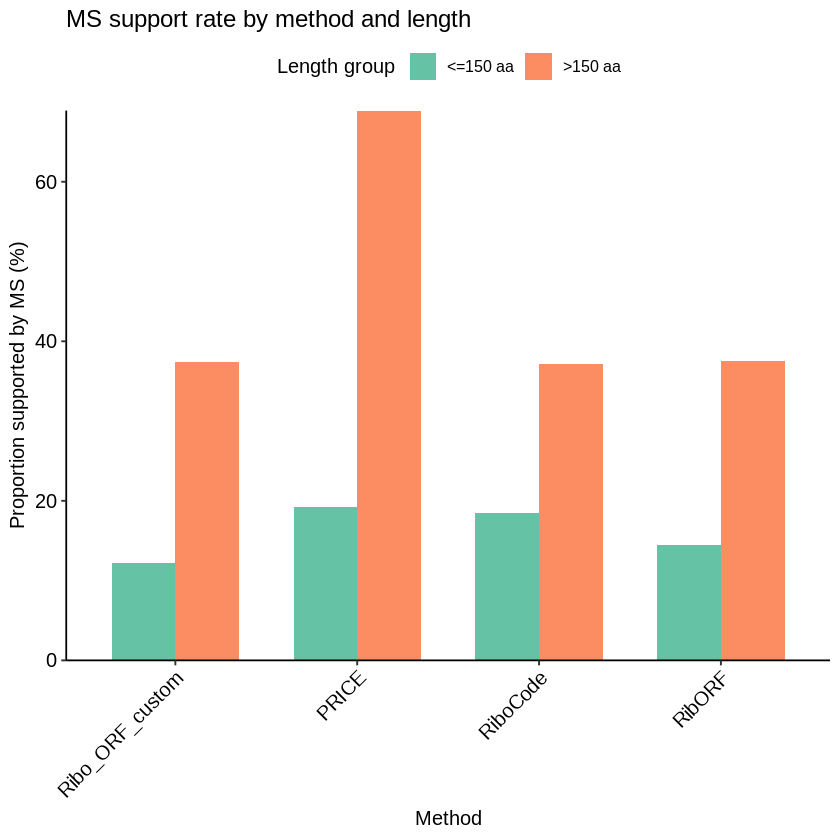

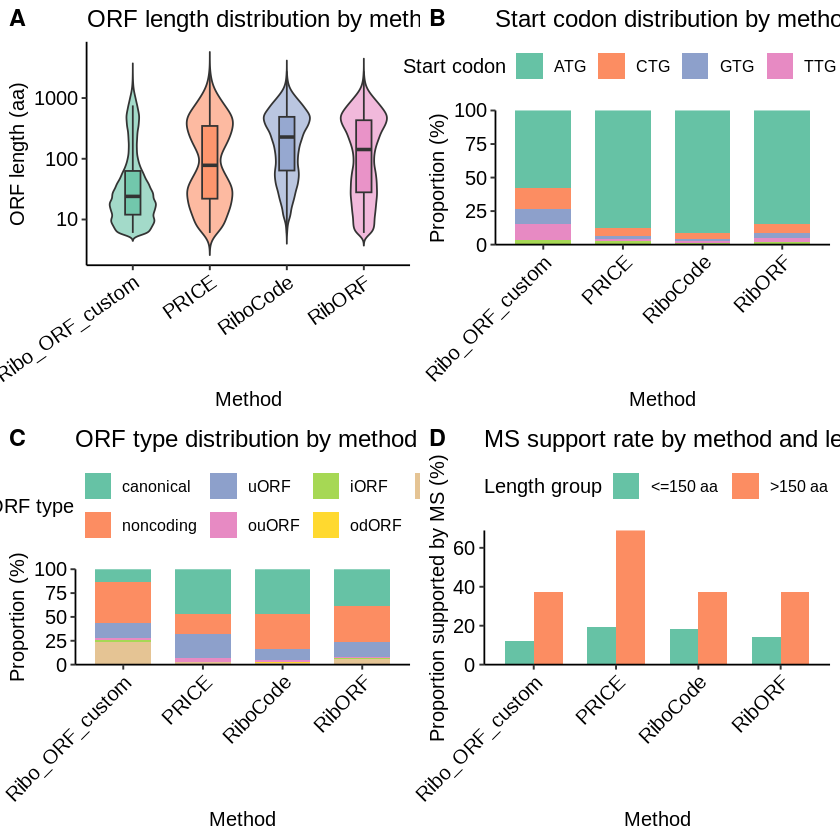

In [49]:
# 加载必要的绘图包
library(UpSetR)
library(patchwork)
library(cowplot)

# 设置输出路径（留空等你补充）
output_path <- "/home/user/data3/lit/project/sORFs/09-CustomDb/formal_20250821/figures/new-MS-res-with-public"

# ===== 定义方法显示顺序 =====
method_order <- c("Ribo_ORF_custom", "PRICE", "RiboCode", "RibORF")

# ===== 1. UpSet Plot =====
# 准备UpSet数据
upset_data <- df %>%
  select(ORF_id, Is_PRICE, Is_RiboCode, Is_RibORF, Is_Ribo_ORF_custom) %>%
  mutate(across(starts_with("Is_"), ~ifelse(. == TRUE, 1, 0)))

# 绘制UpSet plot
pdf(o("upset_plot.pdf"), width = 10, height = 6)
upset(upset_data, 
      sets = c("Is_Ribo_ORF_custom", "Is_PRICE", "Is_RiboCode", "Is_RibORF"),
#       keep.order = TRUE,
      order.by = "freq",
      text.scale = 1.5,
      point.size = 3,
      line.size = 1,
      mainbar.y.label = "ORF intersection size",
      sets.x.label = "Total ORFs per method")
dev.off()

# ===== 2. 长度分布图 =====
# 准备长度数据

length_data <- df %>%
  pivot_longer(cols = starts_with("Is_"), 
               names_to = "Method", 
               values_to = "Identified") %>%
  filter(Identified == TRUE) %>%
  mutate(Method = gsub("Is_", "", Method),
         Method = factor(Method, levels = method_order))

violin_plot <- function(df, x, y, fill = x,
                        type_colors = NULL,
                        y_breaks = c(0.01, 0.1, 1, 10, 100),
                        y_label = "NC ratio") {
  ggplot(df, aes(x = {{x}}, y = {{y}}, fill = {{fill}})) +
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    { if (!is.null(type_colors)) scale_fill_manual(values = type_colors) else scale_fill_brewer(palette = "Set2") } +
    labs(x = NULL, y = y_label) +
    guides(fill = "none") +
    theme_3(rotate = T)
}
    
violin_plot(length_data , x = Method, y = ORF_length, fill = Method,y_label = "Translation efficiency")+
scale_y_log10()+
  labs(x = "Method", 
       y = "ORF length (aa)",
       title = "ORF length distribution by method") -> p_length_violin
    
p_length_violin    

# ===== 3. 起始密码子比例（堆积柱状图，等高）=====
codon_data <- df %>%
  pivot_longer(cols = starts_with("Is_"), 
               names_to = "Method", 
               values_to = "Identified") %>%
  filter(Identified == TRUE) %>%
  mutate(Method = gsub("Is_", "", Method),
         Method = factor(Method, levels = method_order)) %>%
  group_by(Method, Start_codon) %>%
  summarise(Count = n(), .groups = "drop") %>%
  group_by(Method) %>%
  mutate(Proportion = Count / sum(Count) * 100)

codon_data$Start_codon <- factor(codon_data$Start_codon,levels = c("ATG","CTG","GTG","TTG","ACG"))
p_codon <- ggplot(codon_data, aes(x = Method, y = Proportion, fill = Start_codon)) +
  geom_bar(stat = "identity", position = "stack", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "Method", 
       y = "Proportion (%)",
       fill = "Start codon",
       title = "Start codon distribution by method") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_codon

ggsave(o("codon_proportion.pdf"), p_codon, width = 8, height = 6)

# ===== 4. ORF类型比例（堆积柱状图，等高）=====
type_data <- df %>%
  pivot_longer(cols = starts_with("Is_"), 
               names_to = "Method", 
               values_to = "Identified") %>%
  filter(Identified == TRUE) %>%
  mutate(Method = gsub("Is_", "", Method),
         Method = factor(Method, levels = method_order)) %>%
  group_by(Method, ORF_type) %>%
  summarise(Count = n(), .groups = "drop") %>%
  group_by(Method) %>%
  mutate(Proportion = Count / sum(Count) * 100)
type_data$ORF_type <- factor(type_data$ORF_type,levels = c("canonical","noncoding","uORF","ouORF","iORF","odORF","dORF"))
p_type <- ggplot(type_data, aes(x = Method, y = Proportion, fill = ORF_type)) +
  geom_bar(stat = "identity", position = "stack", width = 0.7) +
 scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "Method", 
       y = "Proportion (%)",
       fill = "ORF type",
       title = "ORF type distribution by method") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_type

ggsave(o("type_proportion.pdf"), p_type, width = 8, height = 6)

# ===== 5. MS支持比例（分长度）=====
# 准备MS数据，分长度组
ms_data <- df %>%
  pivot_longer(cols = starts_with("Is_"), 
               names_to = "Method", 
               values_to = "Identified") %>%
  filter(Identified == TRUE) %>%
  mutate(Method = gsub("Is_", "", Method),
         Method = factor(Method, levels = method_order),
         Length_group = ifelse(ORF_length > 150, ">150 aa", "<=150 aa"),
         MS_supported = ifelse(MS_evidence_level_1 == TRUE, TRUE, FALSE))

# 5a. 被MS支持的ORF比例（按方法和长度分组）
ms_support_data <- ms_data %>%
  group_by(Method, Length_group) %>%
  summarise(Total = n(),
            MS_supported_count = sum(MS_supported, na.rm = TRUE),
            .groups = "drop") %>%
  mutate(Proportion = MS_supported_count / Total * 100)

p_ms_support <- ggplot(ms_support_data, aes(x = Method, y = Proportion, fill = Length_group)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "Method", 
       y = "Proportion supported by MS (%)",
       fill = "Length group",
       title = "MS support rate by method and length") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_ms_support

ggsave(o("ms_support.pdf"), p_ms_support, width = 8, height = 6)


# # ===== 组合图形 =====
# # 使用 cowplot 包来组合
combined_plot1 <- plot_grid(p_length_violin, p_codon, p_type, p_ms_support, 
                            ncol = 2, nrow = 2, labels = "AUTO")
combined_plot1

ggsave(o("combined_plot1.pdf"), combined_plot1, width = 14, height = 15)

In [35]:
length_data %>% group_by(Method) %>% summarise(median(ORF_length))
codon_data
type_data

Method,median(ORF_length)
<fct>,<dbl>
Ribo_ORF_custom,24
PRICE,78
RiboCode,228
RibORF,142


Method,Start_codon,Count,Proportion
<fct>,<chr>,<int>,<dbl>
Ribo_ORF_custom,ACG,5791,3.445158
Ribo_ORF_custom,ATG,96667,57.508730
Ribo_ORF_custom,CTG,27176,16.167433
Ribo_ORF_custom,GTG,18114,10.776306
Ribo_ORF_custom,TTG,20343,12.102373
PRICE,ACG,72,2.345277
PRICE,ATG,2700,87.947883
PRICE,CTG,163,5.309446
PRICE,GTG,80,2.605863


Method,ORF_type,Count,Proportion
<fct>,<chr>,<int>,<dbl>
Ribo_ORF_custom,canonical,21861,13.00545538
Ribo_ORF_custom,dORF,39593,23.55450322
Ribo_ORF_custom,iORF,3589,2.13515298
Ribo_ORF_custom,noncoding,73667,43.82566586
Ribo_ORF_custom,odORF,1059,0.63001588
Ribo_ORF_custom,ouORF,3387,2.01497998
Ribo_ORF_custom,uORF,24935,14.83422670
PRICE,canonical,1436,46.77524430
PRICE,dORF,70,2.28013029


In [36]:
ms_support_data

Method,Length_group,Total,MS_supported_count,Proportion
<fct>,<chr>,<int>,<int>,<dbl>
Ribo_ORF_custom,<=150 aa,140024,17112,12.22076
Ribo_ORF_custom,>150 aa,28067,10501,37.41404
PRICE,<=150 aa,1757,337,19.18042
PRICE,>150 aa,1313,905,68.92612
RiboCode,<=150 aa,16559,3051,18.42503
RiboCode,>150 aa,24150,8985,37.20497
RibORF,<=150 aa,26163,3773,14.42113
RibORF,>150 aa,25238,9471,37.52675


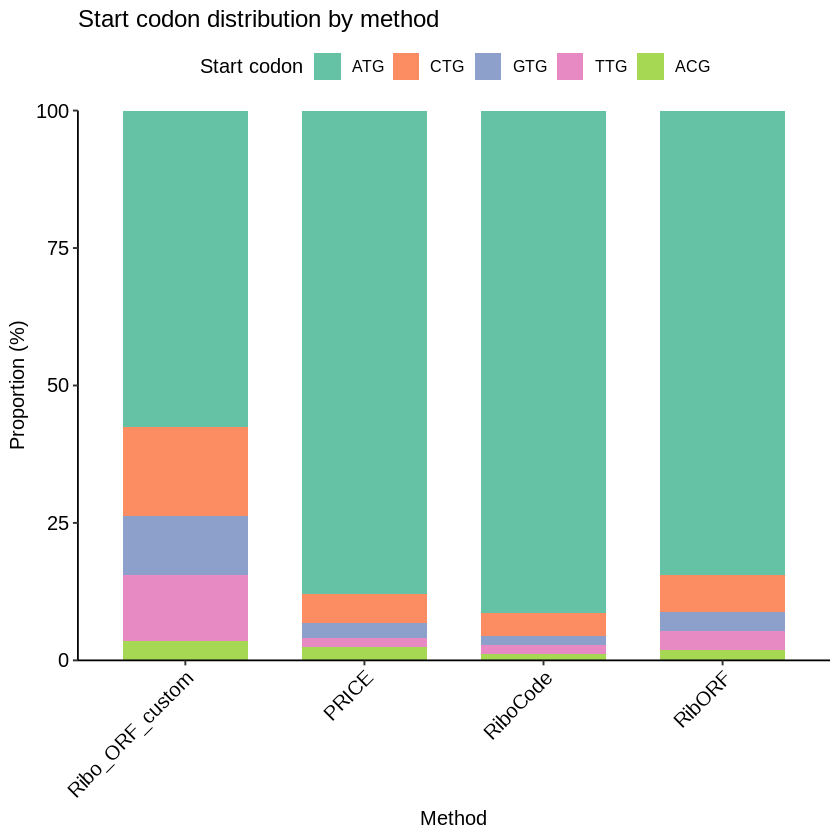

In [37]:

codon_data$Start_codon  <- factor(codon_data$Start_codon,levels=c("ATG","CTG","GTG","TTG","ACG"))
p_codon <- ggplot(codon_data, aes(x = Method, y = Proportion, fill = Start_codon)) +
  geom_bar(stat = "identity", position = "stack", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "Method", 
       y = "Proportion (%)",
       fill = "Start codon",
       title = "Start codon distribution by method") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
p_codon

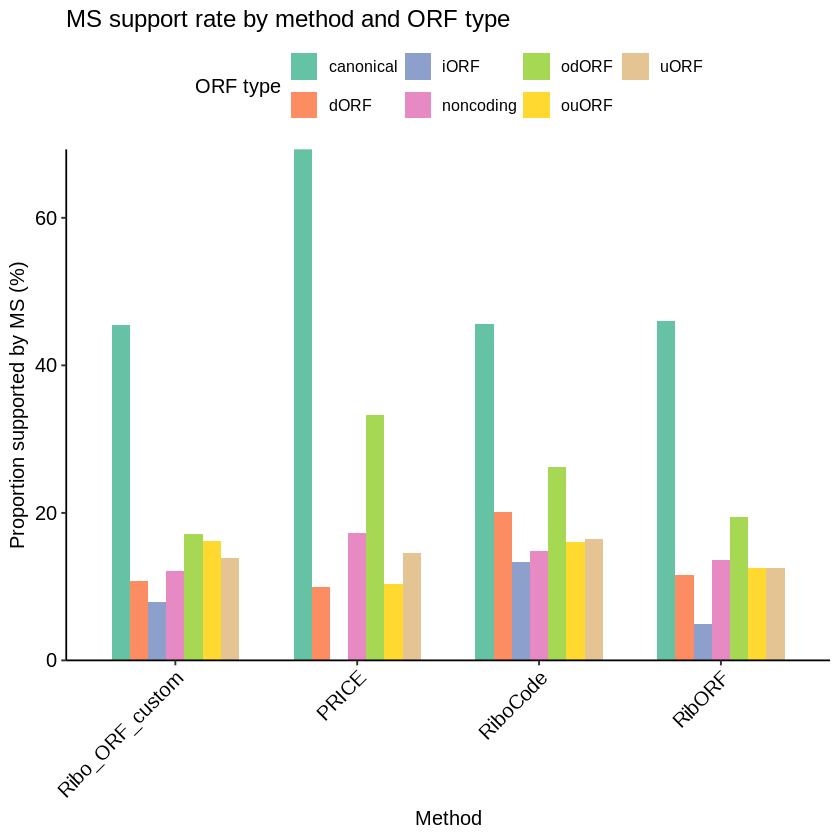

In [38]:
# 5b. 被MS支持的ORF比例（按方法和ORF类型分组）
ms_support_type_data <- ms_data %>%
  group_by(Method, ORF_type) %>%
  summarise(Total = n(),
            MS_supported_count = sum(MS_supported, na.rm = TRUE),
            .groups = "drop") %>%
  mutate(Proportion = MS_supported_count / Total * 100)

p_ms_support_type <- ggplot(ms_support_type_data, aes(x = Method, y = Proportion, fill = ORF_type)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(expand = c(0, 0)) +
  labs(x = "Method", 
       y = "Proportion supported by MS (%)",
       fill = "ORF type",
       title = "MS support rate by method and ORF type") +
  theme_3() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_ms_support_type

ggsave(o("ms_support_by_type.pdf"), p_ms_support_type, width = 10, height = 6)

In [39]:
ms_support_type_data

Method,ORF_type,Total,MS_supported_count,Proportion
<fct>,<chr>,<int>,<int>,<dbl>
Ribo_ORF_custom,canonical,21861,9932,45.432505
Ribo_ORF_custom,dORF,39593,4266,10.774632
Ribo_ORF_custom,iORF,3589,284,7.913068
Ribo_ORF_custom,noncoding,73667,8937,12.131619
Ribo_ORF_custom,odORF,1059,181,17.091596
Ribo_ORF_custom,ouORF,3387,549,16.209035
Ribo_ORF_custom,uORF,24935,3464,13.892120
PRICE,canonical,1436,995,69.289694
PRICE,dORF,70,7,10.000000


In [40]:
length_data %>% head()
table(length_data$Method)
sum(all_orfs_3$Is_PRICE)
sum(all_orfs_3$Is_RiboCode)
sum(all_orfs_3$Is_RibORF)

ORF_id,ORF_length,Start_codon,ORF_type,MS_evidence_level_1,Method,Identified
<chr>,<int>,<chr>,<chr>,<lgl>,<fct>,<lgl>
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,RiboCode,TRUE
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,RibORF,TRUE
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,Ribo_ORF_custom,TRUE
PB.100.1:chr1:-|30|2138:406:496|noncoding|GTG,29,GTG,noncoding,NA,Ribo_ORF_custom,TRUE
PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,60,ATG,noncoding,TRUE,Ribo_ORF_custom,TRUE
PB.1000.1:chr1:+|121|1855:1798:1843|dORF|TTG,14,TTG,dORF,NA,Ribo_ORF_custom,TRUE



Ribo_ORF_custom           PRICE        RiboCode          RibORF 
         168091            3070           40709           51401 

[1] 3070

[1] 40709

[1] 51401

In [41]:
all_orfs_3 %>% filter(ORF_length<=150) -> tmp
sum(tmp  %>% .$MS_evidence_level_1 %>% na.omit() )
14029/nrow(tmp)
table(all_orfs_3$ORF_type)
head(ms_data)
ms_support_data

[1] 17112

[1] 0.10019


canonical      dORF      iORF noncoding     odORF     ouORF      uORF 
    21861     39593      3589     73667      1059      3387     24935 

ORF_id,ORF_length,Start_codon,ORF_type,MS_evidence_level_1,Method,Identified,Length_group,MS_supported
<chr>,<int>,<chr>,<chr>,<lgl>,<fct>,<lgl>,<chr>,<lgl>
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,RiboCode,TRUE,<=150 aa,TRUE
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,RibORF,TRUE,<=150 aa,TRUE
PB.100.1:chr1:-|3|2138:31:382|noncoding|ATG,116,ATG,noncoding,TRUE,Ribo_ORF_custom,TRUE,<=150 aa,TRUE
PB.100.1:chr1:-|30|2138:406:496|noncoding|GTG,29,GTG,noncoding,NA,Ribo_ORF_custom,TRUE,<=150 aa,NA
PB.100.1:chr1:-|34|2138:488:671|noncoding|ATG,60,ATG,noncoding,TRUE,Ribo_ORF_custom,TRUE,<=150 aa,TRUE
PB.1000.1:chr1:+|121|1855:1798:1843|dORF|TTG,14,TTG,dORF,NA,Ribo_ORF_custom,TRUE,<=150 aa,NA


Method,Length_group,Total,MS_supported_count,Proportion
<fct>,<chr>,<int>,<int>,<dbl>
Ribo_ORF_custom,<=150 aa,140024,17112,12.22076
Ribo_ORF_custom,>150 aa,28067,10501,37.41404
PRICE,<=150 aa,1757,337,19.18042
PRICE,>150 aa,1313,905,68.92612
RiboCode,<=150 aa,16559,3051,18.42503
RiboCode,>150 aa,24150,8985,37.20497
RibORF,<=150 aa,26163,3773,14.42113
RibORF,>150 aa,25238,9471,37.52675
